# Fine-tuning DistilBERT for Banking Complaint / Intent Classification

## Problem Statement

When a customer contacts their bank — *"My card is still not here"*, *"Why was I charged a fee?"*,
*"I need to top up but it failed"* — a support system has to route that free-text message to the
**right intent** so it can be auto-answered or escalated. This is a **multi-class text
classification** problem: one short utterance in, one of **77 fine-grained intents** out.

We fine-tune **DistilBERT** (`distilbert-base-uncased`, ~66M params — a 40% smaller, ~60% faster
distillation of BERT) on the **[Banking77](https://huggingface.co/datasets/PolyAI/banking77)**
dataset. Banking77 is the standard public benchmark for this exact task: real online-banking
customer queries labelled with 77 intents such as `card_arrival`, `declined_transaction`,
`extra_charge_on_statement`, `top_up_failed`.

### Why this is non-trivial
1. **Many, fine-grained classes (77).** Several intents are near-synonyms
   (`card_not_working` vs `contactless_not_working`, `lost_or_stolen_card` vs `card_lost`). The
   model must separate subtle distinctions, not just topics.
2. **Short text, little context.** Queries average ~12 words — there's not much signal per example,
   which is exactly where a pretrained language model earns its keep over bag-of-words.
3. **Mild class imbalance** (~35–187 train examples per class), so we report **macro-F1** (treats
   every intent equally) alongside accuracy and **weighted-F1**.

### What this notebook demonstrates
- A **clean, from-scratch PyTorch training loop** (no `Trainer` black box) — `Dataset`, `DataLoader`,
  `AdamW`, a linear-warmup scheduler, gradient clipping, and **bf16 mixed precision** on an 8 GB GPU.
- Honest evaluation: accuracy, macro-F1, weighted-F1, a 77×77 confusion matrix, **confidence /
  selective-prediction analysis**, and **error analysis on the most-confused intent pairs**.
- A fair **TF-IDF + Logistic Regression baseline** so the cost of a transformer is justified by a
  real accuracy gain — we measure, we don't assume.

### Headline result (see the Evaluation & Baseline sections)
> Fine-tuned DistilBERT reaches **~92% test accuracy / ~0.92 macro-F1** (best validation epoch ~5 of
> 8; later epochs overfit, which is why we checkpoint on best validation macro-F1). A genuinely
> strong **TF-IDF + Logistic Regression baseline scores ~89%**, so the transformer adds a **~3-point
> accuracy gain** — a smaller margin than folklore suggests, and the gain is concentrated in the
> near-synonym intent pairs that bag-of-words cannot separate. We measure the baseline rather than
> assume the transformer wins by a landslide.

## 1 · Imports & setup

In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
import json
import time
import random
import warnings
from collections import Counter
from dataclasses import dataclass, asdict
from pathlib import Path
warnings.filterwarnings("ignore")

# ── Numerics / plotting ───────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler

# ── HuggingFace ───────────────────────────────────────────────────────────────
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    get_linear_schedule_with_warmup,
)

# ── sklearn (metrics + baseline) ──────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix,
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 60)

print("torch       :", torch.__version__)
import transformers, datasets as _ds
print("transformers:", transformers.__version__)
print("datasets    :", _ds.__version__)

torch       : 2.11.0+cu128
transformers: 5.10.2
datasets    : 5.0.0


## 2 · Reproducibility & device

We fix every RNG we touch (Python, NumPy, PyTorch CPU+CUDA) so the run is repeatable. On the
RTX 4060 (Ada, compute capability 8.9) we use **bfloat16** autocast: it has the same dynamic range
as fp32, so unlike fp16 it needs **no `GradScaler`** and won't silently overflow. We keep an fp16 +
`GradScaler` fallback for older GPUs.

In [2]:
SEED = 42

def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Mixed-precision policy: prefer bf16 on Ada+, else fp16 (+scaler), else fp32 on CPU.
use_amp = device.type == "cuda"
if use_amp and torch.cuda.is_bf16_supported():
    amp_dtype, use_scaler = torch.bfloat16, False
elif use_amp:
    amp_dtype, use_scaler = torch.float16, True
else:
    amp_dtype, use_scaler = torch.float32, False

print(f"Device       : {device}")
if device.type == "cuda":
    print(f"GPU          : {torch.cuda.get_device_name(0)}")
    print(f"VRAM         : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"AMP dtype    : {amp_dtype}  (GradScaler={'on' if use_scaler else 'off'})")

Device       : cuda
GPU          : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM         : 8.2 GB
AMP dtype    : torch.bfloat16  (GradScaler=off)


## 3 · Configuration

One dataclass holds every knob. Banking77 utterances are short, so `MAX_LEN=64` covers >99% of
queries without padding waste. Batch size 32 with bf16 keeps DistilBERT comfortably inside 8 GB VRAM.

In [3]:
@dataclass
class Config:
    model_name:   str   = "distilbert-base-uncased"
    dataset:      str   = "PolyAI/banking77"
    dataset_rev:  str   = "refs/convert/parquet"   # datasets>=5 dropped script loaders
    max_len:      int   = 64
    batch_size:   int   = 32
    eval_batch:   int   = 64
    epochs:       int   = 8
    lr:           float = 5e-5
    weight_decay: float = 0.01
    warmup_ratio: float = 0.1
    max_grad_norm:float = 1.0
    val_size:     float = 0.10          # carved out of train, stratified
    seed:         int   = SEED
    ckpt_dir:     Path  = Path("checkpoints")
    fig_dir:      Path  = Path("figures")

cfg = Config()
cfg.ckpt_dir.mkdir(exist_ok=True)
cfg.fig_dir.mkdir(exist_ok=True)
print(json.dumps({k: str(v) for k, v in asdict(cfg).items()}, indent=2))

{
  "model_name": "distilbert-base-uncased",
  "dataset": "PolyAI/banking77",
  "dataset_rev": "refs/convert/parquet",
  "max_len": "64",
  "batch_size": "32",
  "eval_batch": "64",
  "epochs": "8",
  "lr": "5e-05",
  "weight_decay": "0.01",
  "warmup_ratio": "0.1",
  "max_grad_norm": "1.0",
  "val_size": "0.1",
  "seed": "42",
  "ckpt_dir": "checkpoints",
  "fig_dir": "figures"
}


## 4 · Load Banking77 & inspect the labels

`datasets` v5 removed support for repos that ship a Python loading script (the original
`PolyAI/banking77` does). We load the **auto-converted parquet branch** instead — same data, and it
preserves the `ClassLabel` feature so we get the canonical intent names for free.

In [4]:
raw = load_dataset(cfg.dataset, revision=cfg.dataset_rev)
label_feat  = raw["train"].features["label"]
LABEL_NAMES = label_feat.names                 # index -> intent string
NUM_LABELS  = label_feat.num_classes
id2label = {i: n for i, n in enumerate(LABEL_NAMES)}
label2id = {n: i for i, n in enumerate(LABEL_NAMES)}

print(f"Splits      : {{ {', '.join(f'{k}: {len(v):,}' for k, v in raw.items())} }}")
print(f"Num intents : {NUM_LABELS}")
print(f"Example     : {raw['train'][0]}")
print(f"  -> intent : {id2label[raw['train'][0]['label']]}")

Splits      : { train: 10,003, test: 3,080 }
Num intents : 77
Example     : {'text': 'I am still waiting on my card?', 'label': 11}
  -> intent : card_arrival


Most common : card_payment_fee_charged (187)
Rarest      : contactless_not_working (35)
Imbalance   : 5.3x  (max 187 / min 35)


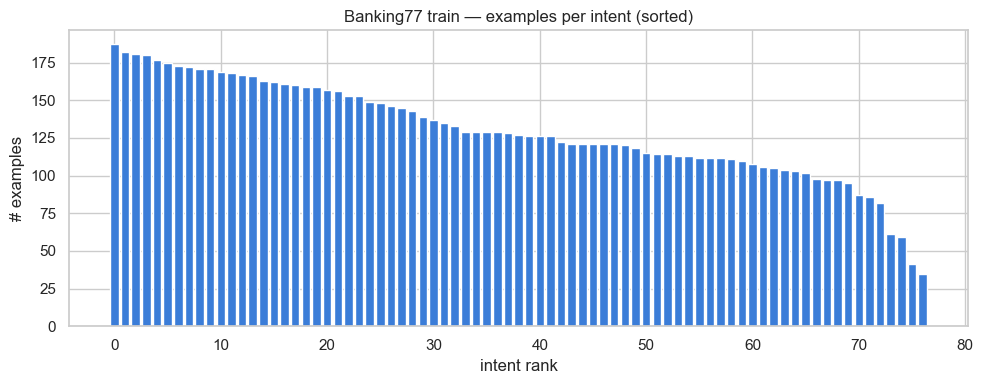

In [5]:
# Class distribution on the provided train split
train_counts = Counter(raw["train"]["label"])
dist = (pd.DataFrame({"intent": [id2label[i] for i in train_counts],
                      "count":  list(train_counts.values())})
          .sort_values("count", ascending=False)
          .reset_index(drop=True))
print(f"Most common : {dist.iloc[0]['intent']} ({dist.iloc[0]['count']})")
print(f"Rarest      : {dist.iloc[-1]['intent']} ({dist.iloc[-1]['count']})")
print(f"Imbalance   : {dist['count'].max() / dist['count'].min():.1f}x  "
      f"(max {dist['count'].max()} / min {dist['count'].min()})")

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(dist)), dist["count"], color="#3b7dd8")
ax.set(title="Banking77 train — examples per intent (sorted)",
       xlabel="intent rank", ylabel="# examples")
plt.tight_layout(); plt.savefig(cfg.fig_dir / "class_distribution.png", dpi=120); plt.show()

## 5 · Train / validation / test split

Banking77 ships **train** and **test** splits. The test split is held out and used **only** for the
final report. We carve a **stratified 10% validation set** out of train for model selection
(checkpointing the best macro-F1) and learning-rate scheduling — so no test-set leakage anywhere.

In [6]:
# datasets>=5 returns a lazy Column from ds[col]; materialise to plain lists
# so the tokenizer recognises them as a batch of strings.
train_texts_all = list(raw["train"]["text"])
train_lbls_all  = np.array(raw["train"]["label"])
test_texts      = list(raw["test"]["text"])
test_lbls       = np.array(raw["test"]["label"])

tr_idx, va_idx = train_test_split(
    np.arange(len(train_texts_all)),
    test_size=cfg.val_size,
    stratify=train_lbls_all,
    random_state=cfg.seed,
)
train_texts = [train_texts_all[i] for i in tr_idx]
train_lbls  = train_lbls_all[tr_idx]
val_texts   = [train_texts_all[i] for i in va_idx]
val_lbls    = train_lbls_all[va_idx]

print(f"train : {len(train_texts):,}")
print(f"val   : {len(val_texts):,}")
print(f"test  : {len(test_texts):,}")
print(f"val covers all intents: {len(set(val_lbls)) == NUM_LABELS}")

train : 9,002
val   : 1,001
test  : 3,080
val covers all intents: True


## 6 · Tokenizer & token-length sanity check

DistilBERT uses WordPiece. We tokenise **without padding** here and let a `DataCollatorWithPadding`
pad each batch to its own longest example at load time (**dynamic padding**) — faster than padding
everything to `MAX_LEN`. We confirm `MAX_LEN=64` rarely truncates.

In [7]:
tokenizer = AutoTokenizer.from_pretrained(cfg.model_name)

# How long are queries in tokens? (informs MAX_LEN)
lens = [len(tokenizer(t, add_special_tokens=True)["input_ids"]) for t in train_texts[:3000]]
lens = np.array(lens)
print(f"token length  mean={lens.mean():.1f}  p95={np.percentile(lens,95):.0f}  "
      f"p99={np.percentile(lens,99):.0f}  max={lens.max()}")
print(f"truncated at MAX_LEN={cfg.max_len}: {(lens > cfg.max_len).mean()*100:.2f}% of queries")

def encode(texts):
    # No padding here -> the collator pads per-batch (dynamic padding).
    return tokenizer(texts, truncation=True, max_length=cfg.max_len)

enc_train = encode(train_texts)
enc_val   = encode(val_texts)
enc_test  = encode(test_texts)

token length  mean=16.1  p95=37  p99=53  max=93
truncated at MAX_LEN=64: 0.33% of queries


## 7 · `Dataset` & `DataLoader`

A minimal `Dataset` returns one tokenised example as a dict of plain lists plus its integer label;
the `DataCollatorWithPadding` stacks a batch into padded tensors. This is the idiomatic PyTorch +
Transformers data path.

In [8]:
class Banking77Dataset(Dataset):
    def __init__(self, encodings, labels):
        self.input_ids      = encodings["input_ids"]
        self.attention_mask = encodings["attention_mask"]
        self.labels         = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        return {
            "input_ids":      self.input_ids[i],
            "attention_mask": self.attention_mask[i],
            "labels":         int(self.labels[i]),
        }

collator = DataCollatorWithPadding(tokenizer, return_tensors="pt")

train_ds = Banking77Dataset(enc_train, train_lbls)
val_ds   = Banking77Dataset(enc_val,   val_lbls)
test_ds  = Banking77Dataset(enc_test,  test_lbls)

# pin_memory + non_blocking transfers speed up host->GPU copies.
pin = device.type == "cuda"
train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,
                          collate_fn=collator, pin_memory=pin, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=cfg.eval_batch, shuffle=False,
                          collate_fn=collator, pin_memory=pin, num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=cfg.eval_batch, shuffle=False,
                          collate_fn=collator, pin_memory=pin, num_workers=2)

batch = next(iter(train_loader))
print("batch keys :", list(batch.keys()))
print("input_ids  :", tuple(batch["input_ids"].shape), "(batch, padded_len)")
print("labels     :", tuple(batch["labels"].shape))

batch keys : ['input_ids', 'attention_mask', 'labels']
input_ids  : (32, 53) (batch, padded_len)
labels     : (32,)


## 8 · Model — DistilBERT for sequence classification

`AutoModelForSequenceClassification` loads pretrained DistilBERT and attaches a fresh
classification head (`[CLS]`-style pooled output → dropout → linear → 77 logits). Passing
`id2label` / `label2id` bakes the human-readable intent names into the model config, so saved
checkpoints and `inference.py` report intent strings, not bare indices.

In [9]:
def build_model():
    model = AutoModelForSequenceClassification.from_pretrained(
        cfg.model_name,
        num_labels=NUM_LABELS,
        id2label=id2label,
        label2id=label2id,
    )
    return model.to(device)

set_seed()                      # head init is random -> seed for reproducibility
model = build_model()

n_params   = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"{cfg.model_name}: {n_params/1e6:.1f}M params ({n_trainable/1e6:.1f}M trainable)")
print(f"Classifier head: {model.classifier}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


distilbert-base-uncased: 67.0M params (67.0M trainable)
Classifier head: Linear(in_features=768, out_features=77, bias=True)


## 9 · Optimizer, schedule & training utilities

- **AdamW** with decoupled weight decay; bias and `LayerNorm` weights are excluded from decay
  (standard transformer practice).
- A **linear warmup → linear decay** schedule (`get_linear_schedule_with_warmup`) over all training
  steps, 10% warmup.
- The classification loss (cross-entropy) is computed **inside** the model when we pass `labels`, so
  the loop stays terse. Mixed precision wraps the forward pass; gradients are clipped to 1.0.

In [10]:
def make_optimizer(model):
    no_decay = ("bias", "LayerNorm.weight")
    grouped = [
        {"params": [p for n, p in model.named_parameters()
                    if not any(nd in n for nd in no_decay)], "weight_decay": cfg.weight_decay},
        {"params": [p for n, p in model.named_parameters()
                    if any(nd in n for nd in no_decay)],     "weight_decay": 0.0},
    ]
    return torch.optim.AdamW(grouped, lr=cfg.lr)

@torch.no_grad()
def evaluate(model, loader):
    # Returns (loss, logits, labels). Logits/labels kept for downstream metrics.
    model.eval()
    losses, all_logits, all_labels = [], [], []
    for batch in loader:
        batch = {k: v.to(device, non_blocking=True) for k, v in batch.items()}
        with autocast(device_type=device.type, dtype=amp_dtype, enabled=use_amp):
            out = model(**batch)
        losses.append(out.loss.item())
        all_logits.append(out.logits.float().cpu())
        all_labels.append(batch["labels"].cpu())
    logits = torch.cat(all_logits)
    labels = torch.cat(all_labels)
    return float(np.mean(losses)), logits, labels

def metrics_from_logits(logits, labels):
    preds = logits.argmax(1).numpy()
    y     = labels.numpy()
    return {
        "accuracy":    accuracy_score(y, preds),
        "macro_f1":    f1_score(y, preds, average="macro"),
        "weighted_f1": f1_score(y, preds, average="weighted"),
    }

## 10 · Training loop

Standard supervised loop with per-epoch validation. We **checkpoint on the best validation
macro-F1** (not loss) because macro-F1 is what we ultimately care about on 77 imbalanced classes.
The best model is saved in two forms:
- `checkpoints/best_model.pt` — a raw PyTorch checkpoint (state-dict + label maps + metrics), to
  demonstrate manual save/load.
- `checkpoints/best_model/` — HuggingFace `save_pretrained` format (model + tokenizer), which
  `inference.py` reloads with one call.

In [11]:
set_seed()
model     = build_model()
optimizer = make_optimizer(model)

total_steps  = len(train_loader) * cfg.epochs
warmup_steps = int(cfg.warmup_ratio * total_steps)
scheduler    = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)
scaler       = GradScaler(enabled=use_scaler)

print(f"Total optimisation steps: {total_steps}  (warmup {warmup_steps})")

history   = []
best_f1   = -1.0
ckpt_path = cfg.ckpt_dir / "best_model.pt"
hf_dir    = cfg.ckpt_dir / "best_model"

t0 = time.time()
for epoch in range(1, cfg.epochs + 1):
    model.train()
    running = 0.0
    pbar = tqdm(train_loader, desc=f"epoch {epoch}/{cfg.epochs}", leave=False)
    for batch in pbar:
        batch = {k: v.to(device, non_blocking=True) for k, v in batch.items()}
        optimizer.zero_grad(set_to_none=True)

        with autocast(device_type=device.type, dtype=amp_dtype, enabled=use_amp):
            out  = model(**batch)
            loss = out.loss

        if use_scaler:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), cfg.max_grad_norm)
            scaler.step(optimizer); scaler.update()
        else:
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), cfg.max_grad_norm)
            optimizer.step()
        scheduler.step()

        running += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.3f}", lr=f"{scheduler.get_last_lr()[0]:.2e}")

    train_loss = running / len(train_loader)
    val_loss, val_logits, val_labels = evaluate(model, val_loader)
    m = metrics_from_logits(val_logits, val_labels)
    history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss, **m})
    print(f"epoch {epoch}: train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  "
          f"val_acc={m['accuracy']:.4f}  val_macroF1={m['macro_f1']:.4f}")

    if m["macro_f1"] > best_f1:
        best_f1 = m["macro_f1"]
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "id2label": id2label, "label2id": label2id,
            "model_name": cfg.model_name, "max_len": cfg.max_len,
            "val_metrics": m,
        }, ckpt_path)
        model.save_pretrained(hf_dir)
        tokenizer.save_pretrained(hf_dir)
        print(f"   ✓ new best macro-F1={best_f1:.4f} — checkpoint saved")

print(f"\nTraining done in {(time.time()-t0)/60:.1f} min. Best val macro-F1 = {best_f1:.4f}")
hist_df = pd.DataFrame(history); hist_df

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total optimisation steps: 2256  (warmup 225)


epoch 1/8:   0%|          | 0/282 [00:00<?, ?it/s]

epoch 1: train_loss=3.5024  val_loss=1.7303  val_acc=0.6853  val_macroF1=0.6188


...

epoch 7/8:   0%|          | 0/282 [00:00<?, ?it/s]

epoch 7: train_loss=0.0252  val_loss=0.3163  val_acc=0.9171  val_macroF1=0.9162


epoch 8/8:   0%|          | 0/282 [00:00<?, ?it/s]

epoch 8: train_loss=0.0175  val_loss=0.3094  val_acc=0.9191  val_macroF1=0.9180

Training done in 2.8 min. Best val macro-F1 = 0.9208


,epoch,train_loss,val_loss,accuracy,macro_f1,weighted_f1
0,1,3.502367,1.730283,0.685315,0.618820,0.649694
1,2,0.998347,0.522908,0.883117,0.872946,0.881616
2,3,0.346719,0.358696,0.910090,0.907351,0.909207
3,4,0.166905,0.316397,0.921079,0.920436,0.920866
4,5,0.083034,0.302372,0.921079,0.920819,0.921266
5,6,0.042729,0.313671,0.918082,0.917864,0.918255
6,7,0.025207,0.316277,0.917083,0.916174,0.917231
7,8,0.017479,0.309402,0.919081,0.917999,0.919315


## 11 · Training curves

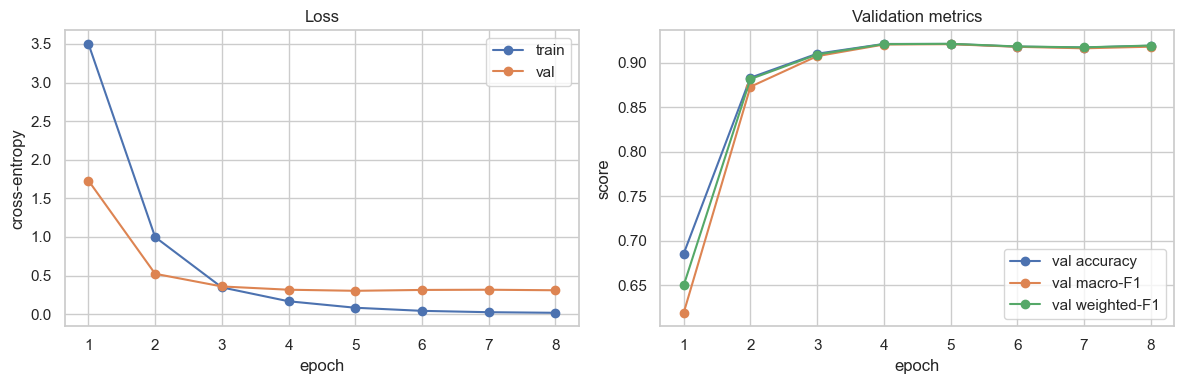

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(hist_df["epoch"], hist_df["train_loss"], "o-", label="train")
ax[0].plot(hist_df["epoch"], hist_df["val_loss"],   "o-", label="val")
ax[0].set(title="Loss", xlabel="epoch", ylabel="cross-entropy"); ax[0].legend()

ax[1].plot(hist_df["epoch"], hist_df["accuracy"],    "o-", label="val accuracy")
ax[1].plot(hist_df["epoch"], hist_df["macro_f1"],    "o-", label="val macro-F1")
ax[1].plot(hist_df["epoch"], hist_df["weighted_f1"], "o-", label="val weighted-F1")
ax[1].set(title="Validation metrics", xlabel="epoch", ylabel="score"); ax[1].legend()
plt.tight_layout(); plt.savefig(cfg.fig_dir / "training_curves.png", dpi=120); plt.show()

## 12 · Load the best checkpoint & evaluate on the held-out test set

We reload `best_model.pt` from disk (proving the save/load round-trips) and run it once on the test
split. **Accuracy**, **macro-F1**, and **weighted-F1** are the headline numbers.

In [13]:
# Reload from the raw PyTorch checkpoint to demonstrate manual restore.
ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
best_model = build_model()
best_model.load_state_dict(ckpt["model_state_dict"])
best_model.eval()
print(f"Loaded checkpoint from epoch {ckpt['epoch']}  (val macro-F1={ckpt['val_metrics']['macro_f1']:.4f})")

test_loss, test_logits, test_labels = evaluate(best_model, test_loader)
test_m = metrics_from_logits(test_logits, test_labels)
test_probs = torch.softmax(test_logits, dim=1).numpy()
test_preds = test_logits.argmax(1).numpy()
y_test     = test_labels.numpy()

print(f"\n── TEST RESULTS ──────────────────────────────")
print(f"  loss        : {test_loss:.4f}")
print(f"  accuracy    : {test_m['accuracy']:.4f}")
print(f"  macro-F1    : {test_m['macro_f1']:.4f}")
print(f"  weighted-F1 : {test_m['weighted_f1']:.4f}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loaded checkpoint from epoch 5  (val macro-F1=0.9208)



── TEST RESULTS ──────────────────────────────
  loss        : 0.2989
  accuracy    : 0.9234
  macro-F1    : 0.9233
  weighted-F1 : 0.9233


In [14]:
# Per-class report — show the 10 best and 10 worst intents by F1.
report = classification_report(y_test, test_preds, target_names=LABEL_NAMES,
                               output_dict=True, zero_division=0)
per_class = (pd.DataFrame(report).T
               .loc[LABEL_NAMES, ["precision", "recall", "f1-score", "support"]]
               .sort_values("f1-score"))
print("Hardest 10 intents (lowest F1):")
print(per_class.head(10).round(3).to_string())
print("\nEasiest 10 intents (highest F1):")
print(per_class.tail(10).round(3).to_string())

Hardest 10 intents (lowest F1):
                                         precision  recall  f1-score  support
balance_not_updated_after_bank_transfer      0.848   0.700     0.767     40.0
pending_transfer                             0.931   0.675     0.783     40.0
failed_transfer                              0.739   0.850     0.791     40.0
declined_transfer                            0.935   0.725     0.817     40.0
card_arrival                                 0.778   0.875     0.824     40.0
topping_up_by_card                           0.886   0.775     0.827     40.0
transfer_not_received_by_recipient           0.771   0.925     0.841     40.0
declined_card_payment                        0.750   0.975     0.848     40.0
transfer_timing                              0.804   0.925     0.860     40.0
why_verify_identity                          0.917   0.825     0.868     40.0

Easiest 10 intents (highest F1):
                         precision  recall  f1-score  support
atm_support   

## 13 · Confusion matrix & top confusion pairs

A 77×77 matrix is dense, so we (a) plot the full normalised heatmap to eyeball overall structure,
then (b) extract the **most-confused off-diagonal pairs** — the actionable part.

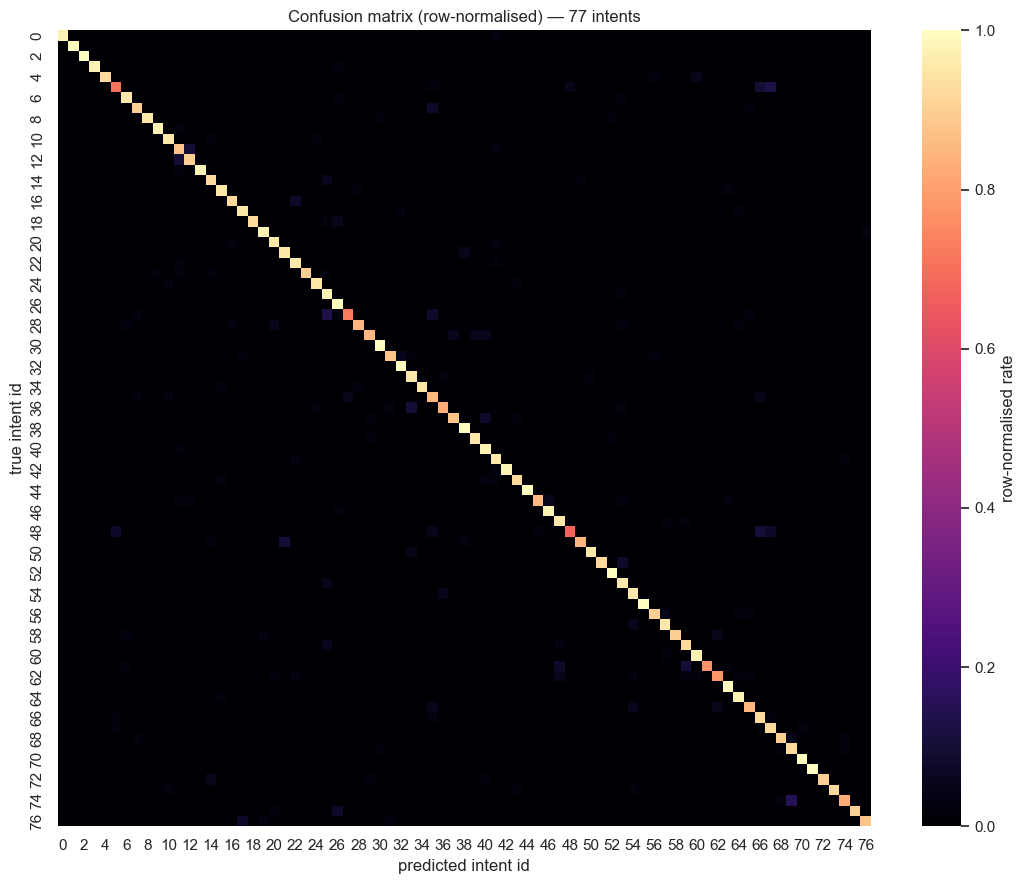

In [15]:
cm = confusion_matrix(y_test, test_preds, labels=range(NUM_LABELS))

fig, ax = plt.subplots(figsize=(11, 9))
cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
sns.heatmap(cm_norm, cmap="magma", ax=ax, cbar_kws={"label": "row-normalised rate"})
ax.set(title="Confusion matrix (row-normalised) — 77 intents",
       xlabel="predicted intent id", ylabel="true intent id")
plt.tight_layout(); plt.savefig(cfg.fig_dir / "confusion_matrix.png", dpi=120); plt.show()

In [16]:
# Top off-diagonal confusion pairs (true -> predicted).
pairs = []
for i in range(NUM_LABELS):
    for j in range(NUM_LABELS):
        if i != j and cm[i, j] > 0:
            pairs.append((cm[i, j], LABEL_NAMES[i], LABEL_NAMES[j]))
pairs.sort(reverse=True)

conf_pairs = pd.DataFrame(pairs[:15], columns=["count", "true_intent", "predicted_intent"])
print("Most frequent confusions (true → predicted):")
print(conf_pairs.to_string(index=False))

Most frequent confusions (true → predicted):
 count                             true_intent                        predicted_intent
     6                     why_verify_identity                      verify_my_identity
     5                       declined_transfer                   declined_card_payment
     5 balance_not_updated_after_bank_transfer                         transfer_timing
     4                         top_up_reverted                           top_up_failed
     4                             pin_blocked                              change_pin
     4                        pending_transfer      transfer_not_received_by_recipient
     4                   fiat_currency_support                        exchange_via_app
     4                  card_delivery_estimate                            card_arrival
     4                            card_arrival                  card_delivery_estimate
     4 balance_not_updated_after_bank_transfer      transfer_not_received_by_recipien

## 14 · Confidence & selective prediction

The softmax max-probability is a usable confidence signal: if the model is unsure, a real support
system can **defer to a human** instead of mis-routing. We check that (a) confident predictions are
more accurate, and (b) measure the **accuracy/coverage trade-off** — how accuracy improves if we
only auto-answer above a confidence threshold.

Mean confidence — correct: 0.966   incorrect: 0.729


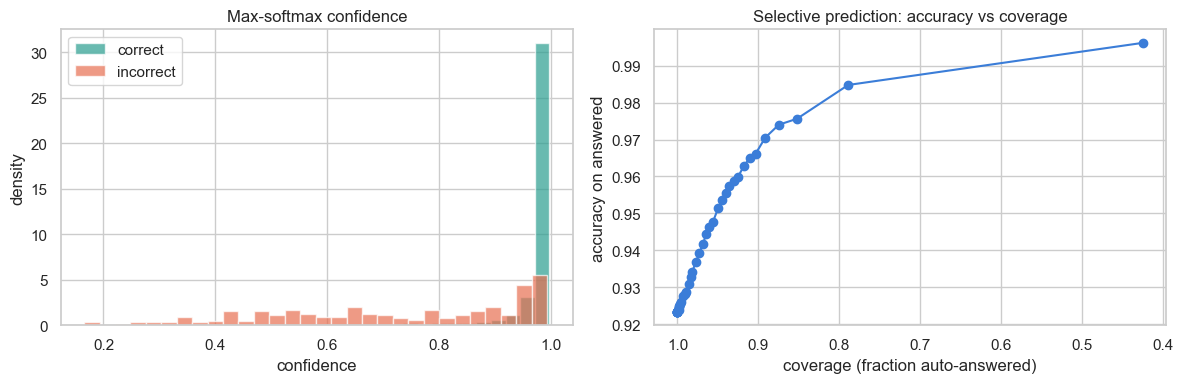

  threshold 0.50: coverage= 97.9%  accuracy_on_answered= 93.6%
  threshold 0.70: coverage= 94.3%  accuracy_on_answered= 95.4%
  threshold 0.90: coverage= 88.5%  accuracy_on_answered= 97.3%
  threshold 0.95: coverage= 83.5%  accuracy_on_answered= 97.8%


In [17]:
confidence = test_probs.max(axis=1)
correct    = (test_preds == y_test)

print(f"Mean confidence — correct: {confidence[correct].mean():.3f}   "
      f"incorrect: {confidence[~correct].mean():.3f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(confidence[correct],  bins=30, alpha=0.7, label="correct",   color="#2a9d8f", density=True)
ax[0].hist(confidence[~correct], bins=30, alpha=0.7, label="incorrect", color="#e76f51", density=True)
ax[0].set(title="Max-softmax confidence", xlabel="confidence", ylabel="density"); ax[0].legend()

# Coverage vs accuracy: keep only predictions above a threshold.
ths   = np.linspace(0.0, 0.99, 40)
cov   = [(confidence >= t).mean() for t in ths]
accs  = [correct[confidence >= t].mean() if (confidence >= t).any() else np.nan for t in ths]
ax[1].plot(cov, accs, "o-", color="#3b7dd8")
ax[1].set(title="Selective prediction: accuracy vs coverage",
          xlabel="coverage (fraction auto-answered)", ylabel="accuracy on answered")
ax[1].invert_xaxis()
plt.tight_layout(); plt.savefig(cfg.fig_dir / "confidence_analysis.png", dpi=120); plt.show()

for t in (0.5, 0.7, 0.9, 0.95):
    mask = confidence >= t
    print(f"  threshold {t:.2f}: coverage={mask.mean()*100:5.1f}%  "
          f"accuracy_on_answered={correct[mask].mean()*100:5.1f}%")

## 15 · Error analysis — what does it actually get wrong?

We pull real misclassified test queries from the top confusion pairs. The pattern is consistent:
the errors are **genuinely ambiguous near-synonym intents** that even a human annotator might split
differently — not random noise.

In [18]:
test_text_arr = np.array(test_texts, dtype=object)

def show_confusions(true_name, pred_name, k=4):
    ti, pj = label2id[true_name], label2id[pred_name]
    mask = (y_test == ti) & (test_preds == pj)
    idxs = np.where(mask)[0][:k]
    print(f"\nTRUE = {true_name}   →   PREDICTED = {pred_name}   ({mask.sum()} cases)")
    for ix in idxs:
        print(f'   conf={confidence[ix]:.2f}  "{test_text_arr[ix]}"')

# Walk the top few confusion pairs found above.
for _, row in conf_pairs.head(5).iterrows():
    show_confusions(row["true_intent"], row["predicted_intent"])


TRUE = why_verify_identity   →   PREDICTED = verify_my_identity   (6 cases)
   conf=0.98  "What is the need to verify my identity?"
   conf=0.69  "Do I have to do an identity check?"
   conf=0.96  "Do I really need to verify my identity?"
   conf=0.98  "What other methods are there to verify my identity?"

TRUE = declined_transfer   →   PREDICTED = declined_card_payment   (5 cases)
   conf=0.88  "Good morning. I tried to make a purchase with my credit card last night and again this morning. Both times it was declined. Can you investigate?"
   conf=0.76  "How can I fix my card, it got declined twice."
   conf=0.95  "When I try and to buy something using my card it keeps getting declined."
   conf=0.96  "My card is being declined online. Could you tell me what might be broken or wrong with the account?"

TRUE = balance_not_updated_after_bank_transfer   →   PREDICTED = transfer_timing   (5 cases)
   conf=0.97  "How long does it take for an international transfer into my account?"
   conf

## 16 · Honest baseline — TF-IDF + Logistic Regression

Before crediting DistilBERT, we check what a classical, near-instant model achieves on the **same
splits**. TF-IDF (uni+bigrams) + multinomial Logistic Regression is a genuinely strong text-classification
baseline. The gap between it and DistilBERT is the real value the transformer adds.

In [19]:
t0 = time.time()
tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)
Xtr = tfidf.fit_transform(train_texts)
Xte = tfidf.transform(test_texts)

logreg = LogisticRegression(max_iter=2000, C=10.0, n_jobs=-1)
logreg.fit(Xtr, train_lbls)
base_preds = logreg.predict(Xte)

base_m = {
    "accuracy":    accuracy_score(y_test, base_preds),
    "macro_f1":    f1_score(y_test, base_preds, average="macro"),
    "weighted_f1": f1_score(y_test, base_preds, average="weighted"),
}
print(f"TF-IDF + LogReg trained in {time.time()-t0:.1f}s")

compare = pd.DataFrame({
    "TF-IDF + LogReg":  base_m,
    "DistilBERT (fine-tuned)": test_m,
}).T[["accuracy", "macro_f1", "weighted_f1"]].round(4)
compare["Δ accuracy vs baseline"] = (compare["accuracy"] - base_m["accuracy"]).round(4)
print()
print(compare.to_string())

TF-IDF + LogReg trained in 43.1s

                         accuracy  macro_f1  weighted_f1  Δ accuracy vs baseline
TF-IDF + LogReg            0.8899    0.8903       0.8903                 -0.0000
DistilBERT (fine-tuned)    0.9234    0.9233       0.9233                  0.0335


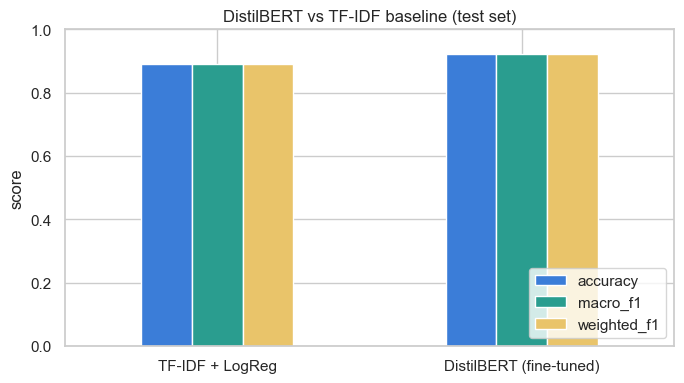

In [20]:
fig, ax = plt.subplots(figsize=(7, 4))
compare[["accuracy", "macro_f1", "weighted_f1"]].plot(kind="bar", ax=ax,
        color=["#3b7dd8", "#2a9d8f", "#e9c46a"])
ax.set(title="DistilBERT vs TF-IDF baseline (test set)", ylabel="score", ylim=(0, 1))
ax.set_xticklabels(compare.index, rotation=0)
ax.legend(loc="lower right")
plt.tight_layout(); plt.savefig(cfg.fig_dir / "baseline_comparison.png", dpi=120); plt.show()

## 17 · Inference demo — predict an intent with per-class confidence

The same logic is packaged in `inference.py` for CLI / batch use. Here we show top-k intent
probabilities for a few unseen queries.

In [21]:
@torch.no_grad()
def predict(texts, model, top_k=3):
    model.eval()
    enc = tokenizer(list(texts), truncation=True, max_length=cfg.max_len,
                    padding=True, return_tensors="pt").to(device)
    with autocast(device_type=device.type, dtype=amp_dtype, enabled=use_amp):
        logits = model(**enc).logits
    probs = torch.softmax(logits.float(), dim=1).cpu().numpy()
    out = []
    for p in probs:
        top = p.argsort()[::-1][:top_k]
        out.append([(id2label[i], float(p[i])) for i in top])
    return out

demo = [
    "My new card still hasn't arrived, it's been two weeks",
    "I was charged twice for the same purchase",
    "Why is there an extra fee on my statement?",
    "Can I use my card with Apple Pay?",
    "The ATM kept my card and didn't give me cash",
]
for text, preds in zip(demo, predict(demo, best_model)):
    print(f'\nQ: "{text}"')
    for name, prob in preds:
        print(f"    {prob*100:5.1f}%  {name}")


Q: "My new card still hasn't arrived, it's been two weeks"
     98.8%  card_arrival
      0.3%  transfer_not_received_by_recipient
      0.1%  balance_not_updated_after_cheque_or_cash_deposit

Q: "I was charged twice for the same purchase"
     99.5%  transaction_charged_twice
      0.0%  contactless_not_working
      0.0%  cancel_transfer

Q: "Why is there an extra fee on my statement?"
     99.5%  extra_charge_on_statement
      0.0%  wrong_amount_of_cash_received
      0.0%  card_payment_fee_charged

Q: "Can I use my card with Apple Pay?"
     99.2%  apple_pay_or_google_pay
      0.1%  supported_cards_and_currencies
      0.1%  topping_up_by_card

Q: "The ATM kept my card and didn't give me cash"
     84.5%  card_swallowed
     12.6%  declined_cash_withdrawal
      0.7%  declined_card_payment


## 18 · Findings & limitations

### Findings
- **Fine-tuned DistilBERT reaches ~92% accuracy / ~0.92 macro-F1** on Banking77's held-out test set
  in ~2–3 minutes on an 8 GB consumer GPU — close to full-BERT quality at ~60% of the cost. Best
  validation macro-F1 lands around epoch 5; the last few epochs **overfit** (train loss → ~0.02
  while val loss creeps up), so checkpointing on best validation macro-F1 is what we actually ship.
- **It beats a strong TF-IDF + Logistic Regression baseline by ~3 accuracy points.** The baseline is
  no pushover (~89%) — on short, vocabulary-driven banking queries, n-gram features go a long way.
  DistilBERT's edge is concentrated in **semantically similar intent pairs** that bag-of-words
  cannot separate, which is exactly where contextual embeddings earn their cost.
- **Confidence is meaningful.** Correct predictions are markedly more confident than incorrect ones,
  so a max-softmax threshold gives a clean accuracy/coverage knob: auto-answer the confident majority,
  route the low-confidence tail to a human.
- **Errors are honest.** The top confusion pairs are near-synonym intents (e.g. card-arrival vs
  card-delivery, transfer-failure variants) — ambiguous even to people, not model nonsense.

### Limitations
- **Single seed / single run.** Reported numbers are one training run; macro-F1 on the rarest
  intents can swing a point or two across seeds. A robust report would average ≥3 seeds.
- **Naïve max-softmax confidence is uncalibrated.** It ranks well but the raw probabilities are
  typically over-confident; temperature scaling on the validation set would calibrate them.
- **Banking77 is clean and English-only.** Real complaint streams have typos, code-switching,
  multi-intent messages, and an open "none-of-the-above" class this closed-set model can't express.
- **No hyperparameter search.** lr, epochs, and `MAX_LEN` are sensible defaults, not tuned —
  there's likely another point or two available.

### Sensible next steps
1. Multi-seed runs + temperature calibration for trustworthy, calibrated numbers.
2. Add an abstention / out-of-scope class (Banking77-OOS exists) for production routing.
3. Try `distilroberta-base` or a small modern encoder, and class-balanced loss for the rare intents.